# Advanced Retrieval with LangChain

In the following notebook, we'll explore various methods of advanced retrieval using LangChain!

We'll touch on:

- Naive Retrieval
- Best-Matching 25 (BM25)
- Multi-Query Retrieval
- Parent-Document Retrieval
- Contextual Compression (a.k.a. Rerank)
- Ensemble Retrieval
- Semantic chunking

We'll also discuss how these methods impact performance on our set of documents with a simple RAG chain.

There will be two breakout rooms:

- 🤝 Breakout Room Part #1
  - Task 1: Getting Dependencies!
  - Task 2: Data Collection and Preparation
  - Task 3: Setting Up QDrant!
  - Task 4-10: Retrieval Strategies
- 🤝 Breakout Room Part #2
  - Activity: Evaluate with Ragas

# 🤝 Breakout Room Part #1

## Task 1: Getting Dependencies!

We're going to need a few specific LangChain community packages, like OpenAI (for our [LLM](https://platform.openai.com/docs/models) and [Embedding Model](https://platform.openai.com/docs/guides/embeddings)) and Cohere (for our [Reranker](https://cohere.com/rerank)).

> You do not need to run the following cells if you are running this notebook locally. 

In [1]:
#!pip install -qU langchain langchain-openai langchain-cohere rank_bm25

We're also going to be leveraging [Qdrant's](https://qdrant.tech/documentation/frameworks/langchain/) (pronounced "Quadrant") VectorDB in "memory" mode (so we can leverage it locally in our colab environment).

In [2]:
#!pip install -qU qdrant-client

We'll also provide our OpenAI key, as well as our Cohere API key.

In [3]:
# api loading utilities

%run ../utils.py 


dotenv loaded


In [4]:
try:
    set_api_key_if_not_present("OPENAI_API_KEY")
    set_api_key_if_not_present("COHERE_API_KEY")
    set_api_key_if_not_present("RAGAS_APP_TOKEN")
    set_api_key_if_not_present("LANGCHAIN_API_KEY", "LANGCHAIN_API_KEY:")
    
except:
    import os
    import getpass
    os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")
    os.environ["OPENAI_API_KEY"] = getpass.getpass("openAI API Key:")
    
from uuid import uuid4
os.environ["LANGCHAIN_TRACING"] = "true"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIM - AIE6.13 Retrievals - {uuid4().hex[0:8]}"

## Task 2: Data Collection and Preparation

We'll be using some reviews from the 4 movies in the John Wick franchise today to explore the different retrieval strategies.

These were obtained from IMDB, and are available in the [AIM Data Repository](https://github.com/AI-Maker-Space/DataRepository).

### Data Collection

We can simply `wget` these from GitHub.

You could use any review data you wanted in this step - just be careful to make sure your metadata is aligned with your choice.

In [5]:
!wget https://raw.githubusercontent.com/AI-Maker-Space/DataRepository/main/jw1.csv -O john_wick_1.csv
!wget https://raw.githubusercontent.com/AI-Maker-Space/DataRepository/main/jw2.csv -O john_wick_2.csv
!wget https://raw.githubusercontent.com/AI-Maker-Space/DataRepository/main/jw3.csv -O john_wick_3.csv
!wget https://raw.githubusercontent.com/AI-Maker-Space/DataRepository/main/jw4.csv -O john_wick_4.csv

--2025-05-21 10:22:47--  https://raw.githubusercontent.com/AI-Maker-Space/DataRepository/main/jw1.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19628 (19K) [text/plain]
Saving to: ‘john_wick_1.csv’

john_wick_1.csv     100%[===================>]  19.17K  --.-KB/s    in 0.03s   

2025-05-21 10:22:48 (625 KB/s) - ‘john_wick_1.csv’ saved [19628/19628]

--2025-05-21 10:22:48--  https://raw.githubusercontent.com/AI-Maker-Space/DataRepository/main/jw2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14747 (14K) [text/plain]
Sav

### Data Preparation

We want to make sure all our documents have the relevant metadata for the various retrieval strategies we're going to be applying today.

- Self-Query: Wants as much metadata as we can provide
- Time-weighted: Wants temporal data

> NOTE: While we're creating a temporal relationship based on when these movies came out for illustrative purposes, it needs to be clear that the "time-weighting" in the Time-weighted Retriever is based on when the document was *accessed* last - not when it was created.

In [6]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from datetime import datetime, timedelta

documents = []

for i in range(1, 5):
  loader = CSVLoader(
      file_path=f"john_wick_{i}.csv",
      metadata_columns=["Review_Date", "Review_Title", "Review_Url", "Author", "Rating"]
  )

  movie_docs = loader.load()
  for doc in movie_docs:

    # Add the "Movie Title" (John Wick 1, 2, ...)
    doc.metadata["Movie_Title"] = f"John Wick {i}"

    # convert "Rating" to an `int`, if no rating is provided - assume 0 rating
    doc.metadata["Rating"] = int(doc.metadata["Rating"]) if doc.metadata["Rating"] else 0

    # newer movies have a more recent "last_accessed_at"
    doc.metadata["last_accessed_at"] = datetime.now() - timedelta(days=4-i)

  documents.extend(movie_docs)

Let's look at an example document to see if everything worked as expected!

In [7]:
documents[0]

Document(metadata={'source': 'john_wick_1.csv', 'row': 0, 'Review_Date': '6 May 2015', 'Review_Title': ' Kinetic, concise, and stylish; John Wick kicks ass.\n', 'Review_Url': '/review/rw3233896/?ref_=tt_urv', 'Author': 'lnvicta', 'Rating': 8, 'Movie_Title': 'John Wick 1', 'last_accessed_at': datetime.datetime(2025, 5, 18, 10, 22, 49, 458587)}, page_content=": 0\nReview: The best way I can describe John Wick is to picture Taken but instead of Liam Neeson it's Keanu Reeves and instead of his daughter it's his dog. That's essentially the plot of the movie. John Wick (Reeves) is out to seek revenge on the people who took something he loved from him. It's a beautifully simple premise for an action movie - when action movies get convoluted, they get bad i.e. A Good Day to Die Hard. John Wick gives the viewers what they want: Awesome action, stylish stunts, kinetic chaos, and a relatable hero to tie it all together. John Wick succeeds in its simplicity.")

## Task 3: Setting up QDrant!

Now that we have our documents, let's create a QDrant VectorStore with the collection name "JohnWick".

We'll leverage OpenAI's [`text-embedding-3-small`](https://openai.com/blog/new-embedding-models-and-api-updates) because it's a very powerful (and low-cost) embedding model.

> NOTE: We'll be creating additional vectorstores where necessary, but this pattern is still extremely useful.

In [8]:
from langchain_community.vectorstores import Qdrant
from langchain_openai import OpenAIEmbeddings
from langchain.embeddings.sentence_transformer import SentenceTransformerEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
#embeddings = SentenceTransformerEmbeddings(model_name="Snowflake/snowflake-arctic-embed-s")

vectorstore = Qdrant.from_documents(
    documents,
    embeddings,
    location=":memory:",
    collection_name="JohnWick"
)

## Task 4: Naive RAG Chain

Since we're focusing on the "R" in RAG today - we'll create our Retriever first.

### R - Retrieval

This naive retriever will simply look at each review as a document, and use cosine-similarity to fetch the 10 most relevant documents.

> NOTE: We're choosing `10` as our `k` here to provide enough documents for our reranking process later

In [9]:
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 10})

### A - Augmented

We're going to go with a standard prompt for our simple RAG chain today! Nothing fancy here, we want this to mostly be about the Retrieval process.

In [10]:
from langchain_core.prompts import ChatPromptTemplate

RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)

### G - Generation

We're going to leverage `gpt-4.1-nano` as our LLM today, as - again - we want this to largely be about the Retrieval process.

In [11]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4o-mini")


### LCEL RAG Chain

We're going to use LCEL to construct our chain.

> NOTE: This chain will be exactly the same across the various examples with the exception of our Retriever!

In [12]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

naive_retrieval_chain = (
    # INVOKE CHAIN WITH: {"question" : "<<SOME USER QUESTION>>"}
    # "question" : populated by getting the value of the "question" key
    # "context"  : populated by getting the value of the "question" key and chaining it into the base_retriever
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    # "context"  : is assigned to a RunnablePassthrough object (will not be called or considered in the next step)
    #              by getting the value of the "context" key from the previous step
    | RunnablePassthrough.assign(context=itemgetter("context"))
    # "response" : the "context" and "question" values are used to format our prompt object and then piped
    #              into the LLM and stored in a key called "response"
    # "context"  : populated by getting the value of the "context" key from the previous step
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

naive_retrieval_chain.name = "naive_chain"


Let's see how this simple chain does on a few different prompts.

> NOTE: You might think that we've cherry picked prompts that showcase the individual skill of each of the retrieval strategies - you'd be correct!

In [13]:
naive_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

Yes, people generally liked "John Wick." Reviews highlight its stylish action, strong performances—especially by Keanu Reeves, and its unique premise, contributing to positive remarks such as being entertaining, thrilling, and a standout in the action genre. While there are some mixed opinions, overall, the film is well-regarded among viewers and critics alike.

In [14]:
naive_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Yes, there is one review with a rating of 10. Here is the URL to that review:

- [A Masterpiece & Brilliant Sequel](https://www.imdb.com/review/rw4854296/?ref_=tt_urv) (Rating: 10)

In [15]:
naive_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In "John Wick," an ex-hit-man named John Wick, played by Keanu Reeves, comes out of retirement to seek vengeance after a group of gangsters kills his dog and steals his car. The dog was a gift from his late wife, and its death triggers a wave of violence and revenge. John Wick, known for his lethal skills, embarks on a relentless quest to target those who wronged him, facing numerous assassins and mobsters along the way. The film showcases intense action sequences, brutal combat, and the exploration of a complex criminal underworld. Ultimately, it highlights themes of loss, vengeance, and the consequences of a life of violence.

Overall, this is not bad! Let's see if we can make it better!

## Task 5: Best-Matching 25 (BM25) Retriever

Taking a step back in time - [BM25](https://www.nowpublishers.com/article/Details/INR-019) is based on [Bag-Of-Words](https://en.wikipedia.org/wiki/Bag-of-words_model) which is a sparse representation of text.

In essence, it's a way to compare how similar two pieces of text are based on the words they both contain.

This retriever is very straightforward to set-up! Let's see it happen down below!


In [16]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(documents)

We'll construct the same chain - only changing the retriever.

In [17]:
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

bm25_retrieval_chain.name="bm25_chain"

Let's look at the responses!

In [18]:
bm25_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

People have had mixed feelings about the "John Wick" series. Some reviews express a strong appreciation for the films, highlighting aspects like innovative action sequences and engaging storytelling. For example, one reviewer described the first "John Wick" as "something special" with a captivating world and smooth action, and rated it highly. However, there are also criticisms, particularly directed at "John Wick: Chapter 4," which was described as "almost three hours of nothing" and deemed the weakest of the series. Overall, while many viewers seem to enjoy the films, there are notable dissenting opinions as well.

In [19]:
bm25_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Based on the provided context, there are no reviews that have a rating of 10.

In [20]:
bm25_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In "John Wick," the story revolves around a retired hitman named John Wick, played by Keanu Reeves. After the death of his wife, John is grieving when a group of thugs break into his home, steal his car, and kill his puppy, which was a final gift from his wife. This brutal act prompts John to come out of retirement and seek revenge against those who wronged him. The movie is known for its beautifully choreographed action scenes and emotional depth, making it a standout in the action genre. It sets the stage for subsequent sequels where the stakes and the world of assassins expand.

It's not clear that this is better or worse - but the `I don't know` isn't great!

## Task 6: Contextual Compression (Using Reranking)

Contextual Compression is a fairly straightforward idea: We want to "compress" our retrieved context into just the most useful bits.

There are a few ways we can achieve this - but we're going to look at a specific example called reranking.

The basic idea here is this:

- We retrieve lots of documents that are very likely related to our query vector
- We "compress" those documents into a smaller set of *more* related documents using a reranking algorithm.

We'll be leveraging Cohere's Rerank model for our reranker today!

All we need to do is the following:

- Create a basic retriever
- Create a compressor (reranker, in this case)

That's it!

Let's see it in the code below!

In [21]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-english-v3.0")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=naive_retriever
)

Let's create our chain again, and see how this does!

In [22]:
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

contextual_compression_retrieval_chain.name = "context_chain"


In [23]:
contextual_compression_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

Yes, people generally liked "John Wick." The reviews highlight the film's action sequences, Keanu Reeves' performance, and its entertaining qualities, with ratings as high as 10. Reviewers appreciated its unique style and the way it broke conventions of traditional action films, indicating a positive reception overall.

In [24]:
contextual_compression_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Yes, there is a review with a rating of 10. Here is the URL to that review:

- [A Masterpiece & Brilliant Sequel](https://www.imdb.com/review/rw4854296/?ref_=tt_urv)

In [25]:
contextual_compression_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In the first movie, "John Wick," an ex-hit-man named John Wick, played by Keanu Reeves, comes out of retirement to seek vengeance against the gangsters who killed his dog and stole his car, which were gifts from his deceased wife. This leads him into a violent confrontation with various criminals and hitmen who are aware of his lethal reputation.

In the sequel, "John Wick 2," after resolving his issues with the Russian mafia, John Wick returns home only to be confronted by mobster Santino D'Antonio. Santino demands that Wick honor an old blood oath and carry out a hit, which leads to further conflict. Wick completes the assignment but is then betrayed, resulting in a seven-million dollar contract placed on his life, drawing numerous assassins after him. Wick vows to take revenge on Santino after the hit is accomplished.

We'll need to rely on something like Ragas to help us get a better sense of how this is performing overall - but it "feels" better!

## Task 7: Multi-Query Retriever

Typically in RAG we have a single query - the one provided by the user.

What if we had....more than one query!

In essence, a Multi-Query Retriever works by:

1. Taking the original user query and creating `n` number of new user queries using an LLM.
2. Retrieving documents for each query.
3. Using all unique retrieved documents as context

So, how is it to set-up? Not bad! Let's see it down below!



In [26]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=naive_retriever, llm=chat_model
)

In [27]:
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

multi_query_retrieval_chain.name = "multi_chain"

In [28]:
multi_query_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

Yes, people generally liked John Wick. The reviews provided reflect a strong appreciation for the action, style, and entertainment value of the films. Many reviewers emphasized the quality of the action sequences and Keanu Reeves' performance, often rating the movies highly (with scores around 8 or 9 out of 10). There are some mixed opinions, particularly regarding the sequels, but overall, the franchise is described as consistent and enjoyable, with many fans recommending it to others.

In [29]:
multi_query_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Yes, there is one review that has a rating of 10. Here is the URL to that review:

- [A Masterpiece & Brilliant Sequel](https://www.imdb.com/review/rw4854296/?ref_=tt_urv) (from John Wick 3)

In [30]:
multi_query_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In "John Wick," an ex-hit-man named John Wick, played by Keanu Reeves, comes out of retirement to seek vengeance after a group of gangsters kill his dog, a gift from his late wife, and steal his car. The plot revolves around Wick's relentless pursuit of the gangsters, which leads him into a violent confrontation with the Russian mob. As he embarks on his quest for retribution, Wick's lethal reputation in the criminal underworld becomes known, and he finds himself targeted by numerous assassins due to a bounty placed on his head. The film showcases intense action sequences and Wick's struggle against those who wronged him, ultimately portraying his transformation from a grieving man into a formidable force of vengeance.

## Task 8: Parent Document Retriever

A "small-to-big" strategy - the Parent Document Retriever works based on a simple strategy:

1. Each un-split "document" will be designated as a "parent document" (You could use larger chunks of document as well, but our data format allows us to consider the overall document as the parent chunk)
2. Store those "parent documents" in a memory store (not a VectorStore)
3. We will chunk each of those documents into smaller documents, and associate them with their respective parents, and store those in a VectorStore. We'll call those "child chunks".
4. When we query our Retriever, we will do a similarity search comparing our query vector to the "child chunks".
5. Instead of returning the "child chunks", we'll return their associated "parent chunks".

Okay, maybe that was a few steps - but the basic idea is this:

- Search for small documents
- Return big documents

The intuition is that we're likely to find the most relevant information by limiting the amount of semantic information that is encoded in each embedding vector - but we're likely to miss relevant surrounding context if we only use that information.

Let's start by creating our "parent documents" and defining a `RecursiveCharacterTextSplitter`.

In [31]:
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient, models

parent_docs = documents
child_splitter = RecursiveCharacterTextSplitter(chunk_size=200)

We'll need to set up a new QDrant vectorstore - and we'll use another useful pattern to do so!

> NOTE: We are manually defining our embedding dimension, you'll need to change this if you're using a different embedding model.

In [32]:
client = QdrantClient(location=":memory:")

client.create_collection(
    collection_name="full_documents",
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

from langchain_qdrant import Qdrant

parent_document_vectorstore = Qdrant(
    collection_name="full_documents", embeddings=OpenAIEmbeddings(model="text-embedding-3-small"), client=client
)

/tmp/ipykernel_105765/3595850111.py:10: LangChainDeprecationWarning: The class `Qdrant` was deprecated in LangChain 0.1.2 and will be removed in 0.5.0. Use :class:`~QdrantVectorStore` instead.
  parent_document_vectorstore = Qdrant(


Now we can create our `InMemoryStore` that will hold our "parent documents" - and build our retriever!

In [33]:
store = InMemoryStore()

parent_document_retriever = ParentDocumentRetriever(
    vectorstore = parent_document_vectorstore,
    docstore=store,
    child_splitter=child_splitter,
)

By default, this is empty as we haven't added any documents - let's add some now!

In [34]:
parent_document_retriever.add_documents(parent_docs, ids=None)

We'll create the same chain we did before - but substitute our new `parent_document_retriever`.

In [35]:
parent_document_retrieval_chain = (
    {"context": itemgetter("question") | parent_document_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

parent_document_retrieval_chain.name = "parent_chain"

Let's give it a whirl!

In [36]:
parent_document_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

From the context provided, it appears that opinions about John Wick are mixed. Some reviews express strong dislike, particularly for "John Wick 4," labeling it as "horrible" and criticizing its plot and fight scenes. However, other reviews indicate that the series as a whole, including "John Wick: Chapter 4," is well received, with praises for its consistency and quality. Overall, while there are negative opinions, there are also positive ones, suggesting that people have varying reactions to the John Wick series.

In [37]:
parent_document_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Yes, there is a review with a rating of 10. Here is the URL to that review:

- [Review by ymyuseda](http://www.imdb.com/review/rw4854296/?ref_=tt_urv)

In [38]:
parent_document_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In "John Wick," the story follows a retired hitman named John Wick, played by Keanu Reeves, who is drawn back into the world of assassination after the death of his beloved dog, a gift from his late wife. The dog is killed by gangsters who also steal his car, leading John to seek vengeance. As he embarks on his quest for retribution, he faces numerous assassins who have a price on his head due to his lethal reputation. The film is filled with intense action, shootouts, and a gripping plot centered around themes of revenge and the consequences of one's past.

In the sequel, "John Wick: Chapter 2," which takes place shortly after the first film, John is forced back into the assassin's world to settle an old debt. He travels to various locations, including Italy, Canada, and Manhattan, and engages in violent confrontations with numerous assassins as he tries to help take over the Assassin's Guild. The movie maintains the high-stakes action and suspense established in the original.

Overall, the performance *seems* largely the same. We can leverage a tool like [Ragas]() to more effectively answer the question about the performance.

## Task 9: Ensemble Retriever

In brief, an Ensemble Retriever simply takes 2, or more, retrievers and combines their retrieved documents based on a rank-fusion algorithm.

In this case - we're using the [Reciprocal Rank Fusion](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf) algorithm.

Setting it up is as easy as providing a list of our desired retrievers - and the weights for each retriever.

In [39]:
from langchain.retrievers import EnsembleRetriever

retriever_list = [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
equal_weighting = [1/len(retriever_list)] * len(retriever_list)

ensemble_retriever = EnsembleRetriever(
    retrievers=retriever_list, weights=equal_weighting
)

We'll pack *all* of these retrievers together in an ensemble.

In [40]:
ensemble_retrieval_chain = (
    {"context": itemgetter("question") | ensemble_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

ensemble_retrieval_chain.name = "ensemble_chain"

Let's look at our results!

In [41]:
ensemble_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

Yes, people generally liked "John Wick." Many reviews express enthusiasm for its action sequences, Keanu Reeves' performance, and its unique approach to the action genre. The film is described as engaging, stylish, and entertaining, with several reviewers labeling it as one of the best action films in recent years. While there are some mixed reviews, particularly regarding the sequels, the overall sentiment toward the first "John Wick" film and the franchise suggests a strong positive reception among audiences.

In [42]:
ensemble_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Yes, there is one review with a rating of 10. Here is the URL to that review:

- [A Masterpiece & Brilliant Sequel](https://www.imdb.com/review/rw4854296/?ref_=tt_urv) (John Wick 3)

In [43]:
ensemble_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In "John Wick," an ex-hitman named John Wick, played by Keanu Reeves, comes out of retirement to seek revenge on the gangsters who killed his dog and stole his car. His dog was a last gift from his deceased wife, and its death pushes him into a violent quest for vengeance. As Wick begins his mission against those responsible, he faces numerous challenges and is pursued by many assassins from the criminal underworld, leading to an intense and chaotic series of action sequences. The film highlights his lethal skills and showcases an elaborate and brutal world of crime, ultimately focusing on themes of loss, retribution, and the consequences of violence.

## Task 10: Semantic Chunking

While this is not a retrieval method - it *is* an effective way of increasing retrieval performance on corpora that have clean semantic breaks in them.

Essentially, Semantic Chunking is implemented by:

1. Embedding all sentences in the corpus.
2. Combining or splitting sequences of sentences based on their semantic similarity based on a number of [possible thresholding methods](https://python.langchain.com/docs/how_to/semantic-chunker/):
  - `percentile`
  - `standard_deviation`
  - `interquartile`
  - `gradient`
3. Each sequence of related sentences is kept as a document!

Let's see how to implement this!

> NOTE: You do not need to run this cell if you're running this locally

In [44]:
#!pip install -qU langchain_experimental

We'll use the `percentile` thresholding method for this example which will:

Calculate all distances between sentences, and then break apart sequences of setences that exceed a given percentile among all distances.

In [45]:
from langchain_experimental.text_splitter import SemanticChunker

semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

Now we can split our documents.

In [46]:
semantic_documents = semantic_chunker.split_documents(documents)

Let's create a new vector store.

In [47]:
semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="JohnWickSemantic"
)

We'll use naive retrieval for this example.

In [48]:
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 10})

Finally we can create our classic chain!

In [49]:
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

And view the results! 🏗️🚢🚀

In [50]:
semantic_retrieval_chain.invoke({"question" : "Did people generally like John Wick?"})["response"].content | markdown_pipe

Yes, people generally liked John Wick. Many reviews highlighted its engaging action sequences, stylish execution, and Keanu Reeves' performance. Reviews expressed enjoyment and recommended the films, although some noted that the sequels varied in their reception. Overall, the franchise has a strong following and is well-regarded among action film enthusiasts.

In [51]:
semantic_retrieval_chain.invoke({"question" : "Do any reviews have a rating of 10? If so - can I have the URLs to those reviews?"})["response"].content | markdown_pipe

Yes, there is a review with a rating of 10. Here is the URL to that review:

- [A Masterpiece & Brilliant Sequel](https://www.imdb.com/review/rw4854296/?ref_=tt_urv)

In [52]:
semantic_retrieval_chain.invoke({"question" : "What happened in John Wick?"})["response"].content | markdown_pipe

In "John Wick," the main character, played by Keanu Reeves, is a retired assassin who is drawn back into his former life when a group of criminals breaks into his home. They beat him up, steal his classic car, and kill his puppy, which was a last gift from his deceased wife. This brutal act propels John Wick on a relentless quest for vengeance against those who wronged him. The film features intense and stylish action sequences as Wick battles against the Russian mobsters, showcasing his skills and determination to reclaim his peace and seek retribution.

# 🤝 Breakout Room Part #2

#### 🏗️ Activity #1

Your task is to evaluate the various Retriever methods against eachother.

You are expected to:

1. Create a "golden dataset"
 - Use Synthetic Data Generation (powered by Ragas, or otherwise) to create this dataset
2. Evaluate each retriever with *retriever specific* Ragas metrics
 - Semantic Chunking is not considered a retriever method and will not be required for marks, but you may find it useful to do a "semantic chunking on" vs. "semantic chunking off" comparision between them
3. Compile these in a list and write a small paragraph about which is best for this particular data and why.

Your analysis should factor in:
  - Cost
  - Latency
  - Performance

> NOTE: This is **NOT** required to be completed in class. Please spend time in your breakout rooms creating a plan before moving on to writing code.

##### HINTS:

- LangSmith provides detailed information about latency and cost.

## 💰 Generate the Golden Dataset using Ragas

In [53]:
from ragas.testset import TestsetGenerator, Testset
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings


In [75]:

# 2. Instantiate your generator
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings(model="text-embedding-3-small"))

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset_count = 16
dataset_name = "john_wick_golden"
filename = f"./{dataset_name}_{dataset_count}.jsonl"

try:
    ragas_dataset = Testset.from_jsonl(filename)
except:
    # 3. Generate testset (this builds the KG internally)
    ragas_dataset = generator.generate_with_langchain_docs(documents, testset_size=dataset_count)
    ragas_dataset.to_jsonl(filename)
ragas_dataset.to_pandas()

Applying SummaryExtractor:   0%|          | 0/44 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/100 [00:00<?, ?it/s]

Node 792ecc2d-ec86-44cd-a127-931ef872006d does not have a summary. Skipping filtering.
Node 79066163-311d-4f7c-8770-81051265e3c4 does not have a summary. Skipping filtering.
Node 404b4f72-3341-4826-8f6e-db944b07a9eb does not have a summary. Skipping filtering.
Node 4399fad1-ebee-42c2-8222-6c11dbace8cd does not have a summary. Skipping filtering.
Node 426a5cea-6513-4cb3-9be6-1d4e915b3e76 does not have a summary. Skipping filtering.
Node b2b9f1d5-81a2-4d21-95d7-a4df3d5a42f6 does not have a summary. Skipping filtering.
Node df2bdbe7-feca-4865-a886-82ce47afd22a does not have a summary. Skipping filtering.
Node 21d90785-2b80-408b-bbd5-dd4c6791957f does not have a summary. Skipping filtering.
Node c6a7948f-8327-46c9-bc2b-1c16804cbee6 does not have a summary. Skipping filtering.
Node 12b41dd5-5ed5-4a30-b6b0-4e50ced919bf does not have a summary. Skipping filtering.
Node 53cd2778-4372-40e1-916f-5bb59ec8b9dc does not have a summary. Skipping filtering.
Node 187d7296-6f4f-449f-a260-3a9684f2f938 d

Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/244 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/18 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,synthesizer_name
0,how is A Good Day to Die Hard bad compared to ...,[: 0\nReview: The best way I can describe John...,A Good Day to Die Hard is considered bad becau...,single_hop_specifc_query_synthesizer
1,Can you tel me more abot the movie John Wick a...,[: 2\nReview: With the fourth installment scor...,John Wick is a film series that has gained imm...,single_hop_specifc_query_synthesizer
2,Who Chad Stahelski in John Wick?,[: 3\nReview: John wick has a very simple reve...,Chad Stahelski is the director of John Wick an...,single_hop_specifc_query_synthesizer
3,Can you explane how the rusian mobsters play a...,[: 4\nReview: Though he no longer has a taste ...,"In the movie John Wick, the Russian mobsters a...",single_hop_specifc_query_synthesizer
4,Who is the Russian in John Wick?,[: 5\nReview: Ultra-violent first entry with l...,The Russian in John Wick is an arrogant Russia...,single_hop_specifc_query_synthesizer
5,Is John Wick a good action movie?,[: 6\nReview: John Wick is one of those few mo...,John Wick is one of those few movies a year th...,single_hop_specifc_query_synthesizer
6,how john wick 3 deal with overused action trop...,[<1-hop>\n\n: 22\nReview: All the below are no...,John Wick 3 contrasts with many overused actio...,multi_hop_abstract_query_synthesizer
7,why do some viewers feel frustration with the ...,[<1-hop>\n\n: 15\nReview: ...totally over-rate...,Some viewers feel frustration with John Wick: ...,multi_hop_abstract_query_synthesizer
8,how john wick show physical punishment and res...,"[<1-hop>\n\n: 0\nReview: No doubt about it, ""J...","In ""John Wick: Chapter 2,"" John Wick, played b...",multi_hop_abstract_query_synthesizer
9,why in john wick series they use katana swords...,[<1-hop>\n\n: 13\nReview: From the very beginn...,"In the John Wick series, particularly in the 4...",multi_hop_abstract_query_synthesizer


In [76]:
ragas_dataset.upload()

Testset uploaded! View at https://app.ragas.io/dashboard/alignment/testset/23036041-2806-4b04-a7e7-c03bffa415d5


'https://app.ragas.io/dashboard/alignment/testset/23036041-2806-4b04-a7e7-c03bffa415d5'

In [77]:
from langsmith import Client

client = Client()

dataset_name = f"RAG - Retrievers Evaluation - {uuid4().hex[0:8]}"
ls_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Evaluation of retrievers on John Wick."
)

# Convert ragas dataset to examples and upload to LangSmith
for i, row in ragas_dataset.to_pandas().iterrows():
    client.create_example(
        inputs={"question": row["user_input"]},
        outputs={"reference_answer": row["reference"]},
        dataset_id=ls_dataset.id
    )


## ⛓️ Run the chains on the responses

### Naive Retrieval Chain

```python
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 10})

naive_retrieval_chain = (
    # INVOKE CHAIN WITH: {"question" : "<<SOME USER QUESTION>>"}
    # "question" : populated by getting the value of the "question" key
    # "context"  : populated by getting the value of the "question" key and chaining it into the base_retriever
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    # "context"  : is assigned to a RunnablePassthrough object (will not be called or considered in the next step)
    #              by getting the value of the "context" key from the previous step
    | RunnablePassthrough.assign(context=itemgetter("context"))
    # "response" : the "context" and "question" values are used to format our prompt object and then piped
    #              into the LLM and stored in a key called "response"
    # "context"  : populated by getting the value of the "context" key from the previous step
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```

---

### BM25 Retrieval Chain

```python
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(documents)

bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```

---

### Contextual Compression Retrieval Chain

```python
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-english-v3.0")
# naive_retriever is defined as vectorstore.as_retriever(search_kwargs={"k" : 10})
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=naive_retriever
)

contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```

---

### Multi-Query Retrieval Chain

```python
from langchain.retrievers.multi_query import MultiQueryRetriever

# naive_retriever is defined as vectorstore.as_retriever(search_kwargs={"k" : 10})
# chat_model is ChatOpenAI(model="gpt-4.1-nano")
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=naive_retriever, llm=chat_model
)

multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```

---

### Parent Document Retrieval Chain

```python
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient, models
from langchain_qdrant import Qdrant # Added this import based on usage

parent_docs = documents
child_splitter = RecursiveCharacterTextSplitter(chunk_size=200)

client = QdrantClient(location=":memory:")

client.create_collection(
    collection_name="full_documents",
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

# embeddings is OpenAIEmbeddings(model="text-embedding-3-small")
parent_document_vectorstore = Qdrant(
    collection_name="full_documents", embeddings=OpenAIEmbeddings(model="text-embedding-3-small"), client=client
)

store = InMemoryStore()

parent_document_retriever = ParentDocumentRetriever(
    vectorstore = parent_document_vectorstore,
    docstore=store,
    child_splitter=child_splitter,
)

if len(parent_document_retriever.docstore.docs) == 0: # don't attempt to store them twice
    parent_document_retriever.add_documents(parent_docs, ids=None)

parent_document_retrieval_chain = (
    {"context": itemgetter("question") | parent_document_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```

---

### Ensemble Retrieval Chain

```python
from langchain.retrievers import EnsembleRetriever

# retriever_list contains previously defined retrievers:
# [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
retriever_list = [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
equal_weighting = [1/len(retriever_list)] * len(retriever_list)

ensemble_retriever = EnsembleRetriever(
    retrievers=retriever_list, weights=equal_weighting
)

ensemble_retrieval_chain = (
    {"context": itemgetter("question") | ensemble_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```

---

### Semantic Retrieval Chain

```python
from langchain_experimental.text_splitter import SemanticChunker
# from langchain_community.vectorstores import Qdrant # Already imported
# from langchain_openai import OpenAIEmbeddings # Already imported

# embeddings is OpenAIEmbeddings(model="text-embedding-3-small")
semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

semantic_documents = semantic_chunker.split_documents(documents)

semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="JohnWickSemantic"
)

semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 10})

semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)
```


In [78]:
from typing import Any, Iterator, List
from langchain_core.runnables import RunnableSerializable, RunnableParallel
from ragas import EvaluationDataset
import asyncio
import nest_asyncio
nest_asyncio.apply()


def enter_chain( chain : RunnableSerializable, question:str) -> str:
    return chain.invoke({"question" : question})["response"].content 

def batch(iterable: List[Any], size: int = 16) -> Iterator[List[Any]]:
    for i in range(0, len(iterable), size):
        yield iterable[i : i + size]


async def aapply_rag_chain(
    rag_chain: RunnableSerializable,
    ragas_testset: Testset,
    batch_size: int = 16,
) -> EvaluationDataset:
    """
    Apply RAG chain to dataset items in parallel batches.

    Args:
        rag_chain: The RAG chain to apply
        ragas_ds: The dataset to process
        batch_size: Number of items to process in each batch
    """
    
    ragas_ds = ragas_testset.to_evaluation_dataset()

    async def process_item(item):
        response = await rag_chain.ainvoke({"question": item.user_input})
        item.response = response["response"].content
        item.retrieved_contexts = [
            context.page_content
            for context in response["context"]
        ]

    # Process items in batches using the batch function
    for batch_items in batch(list(ragas_ds), size=batch_size):
        tasks = [process_item(item) for item in batch_items]
        await asyncio.gather(*tasks)
        
    return ragas_ds

In [79]:
result  = await aapply_rag_chain(naive_retrieval_chain, ragas_dataset)

In [80]:
result.to_pandas()

,user_input,retrieved_contexts,reference_contexts,response,reference
0,how is A Good Day to Die Hard bad compared to ...,[: 0\nReview: The best way I can describe John...,[: 0\nReview: The best way I can describe John...,"""A Good Day to Die Hard"" is considered bad com...",A Good Day to Die Hard is considered bad becau...
1,Can you tel me more abot the movie John Wick a...,"[: 9\nReview: At first glance, John Wick sound...",[: 2\nReview: With the fourth installment scor...,"""John Wick"" is a highly acclaimed action film ...",John Wick is a film series that has gained imm...
2,Who Chad Stahelski in John Wick?,[: 3\nReview: John wick has a very simple reve...,[: 3\nReview: John wick has a very simple reve...,"Chad Stahelski is the director of the ""John Wi...",Chad Stahelski is the director of John Wick an...
3,Can you explane how the rusian mobsters play a...,"[: 18\nReview: When the story begins, John (Ke...",[: 4\nReview: Though he no longer has a taste ...,"In the movie ""John Wick,"" Russian mobsters pla...","In the movie John Wick, the Russian mobsters a..."
4,Who is the Russian in John Wick?,"[: 18\nReview: When the story begins, John (Ke...",[: 5\nReview: Ultra-violent first entry with l...,"The Russian in ""John Wick"" is the son of a Rus...",The Russian in John Wick is an arrogant Russia...
5,Is John Wick a good action movie?,"[: 9\nReview: At first glance, John Wick sound...",[: 6\nReview: John Wick is one of those few mo...,"Yes, ""John Wick"" is generally considered a goo...",John Wick is one of those few movies a year th...
6,how john wick 3 deal with overused action trop...,[: 3\nReview: John wick has a very simple reve...,[<1-hop>\n\n: 22\nReview: All the below are no...,"""John Wick 3"" effectively deals with overused ...",John Wick 3 contrasts with many overused actio...
7,why do some viewers feel frustration with the ...,"[: 0\nReview: No doubt about it, ""John Wick: C...",[<1-hop>\n\n: 15\nReview: ...totally over-rate...,"Some viewers express frustration with ""John Wi...",Some viewers feel frustration with John Wick: ...
8,how john wick show physical punishment and res...,"[: 0\nReview: No doubt about it, ""John Wick: C...","[<1-hop>\n\n: 0\nReview: No doubt about it, ""J...","In the ""John Wick"" movies, particularly noted ...","In ""John Wick: Chapter 2,"" John Wick, played b..."
9,why in john wick series they use katana swords...,[: 3\nReview: John wick has a very simple reve...,[<1-hop>\n\n: 13\nReview: From the very beginn...,"The John Wick series, particularly in the late...","In the John Wick series, particularly in the 4..."


In [81]:
from typing import Dict


chains:Dict[str, RunnableSerializable] = {
    "naive":naive_retrieval_chain,
    "bm25":bm25_retrieval_chain,
    "compression":contextual_compression_retrieval_chain,
    "multi":multi_query_retrieval_chain,
    "parent":parent_document_retrieval_chain,
    "ensemble":ensemble_retrieval_chain,
    "semantic":semantic_retrieval_chain
}

responses = {}

async def process_chain(label, chain):
    print(label)
    try:
        return label, EvaluationDataset.from_jsonl(f"evaluation_datasets/{label}.jsonl")
    except:
        result = await aapply_rag_chain(chain, ragas_dataset)
        result.to_jsonl(f"evaluation_datasets/{label}.jsonl")
        return label, result

tasks = [process_chain(label, chain) for label, chain in chains.items()]
results = await asyncio.gather(*tasks)

for label, result in results:
    responses[label] = result



naive
bm25
compression
multi
parent
ensemble
semantic


## ⌚ Metrics and evaluation

Now, we're going to run some metrics. Here are the interpretations that ChatGPT
gives to a five year old 😀

### Retriever metrics

Let’s imagine you have a big toy box full of picture cards, and you’re playing a game where you need to find the right cards to answer a question. These three scores help you understand how good you are at picking cards:

1. **Context Recall** Recall measures how many of the right cards you found.

    “If there were 5 cards hiding the puppy picture, and I grabbed 3 of them, my Context Recall is like saying I found 3 out of the 5 puppy cards.”

2. **Context Entity Recall** Entity Recall checks if you got at least one of the puppy cards.

    “If I’m looking for any card with a star on it, and I picked 1 star card (even if there were 10 in the pile), I get a thumbs-up—because I found at least one star.”

3. **Context Precision** Precision measures how many of your grabbed cards were actually the ones you wanted.

    “I want to see puppy pictures. If I grab 5 cards but only 2 have puppies on them (and the other 3 are dinosaurs), my Precision is like saying only 2 out of my 5 cards were the right puppy cards.”

### End-to-end metrics

1. **Response Relevancy** “How much of my story is actually about the thing I was asked?”

    “If I tell a story with 10 sentences but only 8 of them talk about puppies (and 2 are about unicorns), Relevancy says I used 8 puppy sentences out of 10.”


2. **Factual Correctness (F1)** “Of all the true puppy facts I could say, how many did I get right — and did I say any wrong ones?”

    “Imagine there are 3 true puppy facts: ‘puppies bark,’ ‘puppies have fur,’ ‘puppies wag their tail.’ I said 2 of them right, missed 1, and also told 1 wrong fact like ‘puppies meow.’ F1 scores me by balancing that I found 2 true facts but also made 1 mistake.”

3. **Faithfulness** “Did I stick to only the cards I picked when telling my story, or did I invent extra stuff?”

    “If my cards only show a puppy, but I say ‘and it can fly,’ I’m not being faithful to my cards. Faithfulness checks I only talk about what my cards actually show.”




In [82]:
from ragas.metrics import (
    LLMContextRecall,
    ContextEntityRecall,
    LLMContextPrecisionWithReference,
    ResponseRelevancy,
    FactualCorrectness,
    Faithfulness,
)
from ragas import evaluate
from ragas.evaluation import EvaluationResult

metrics = [
    # Pure retrieval quality
    LLMContextRecall(),
    ContextEntityRecall(),
    LLMContextPrecisionWithReference(),

    # End-to-end answer quality
    ResponseRelevancy(),
    FactualCorrectness(mode="f1"),
    Faithfulness(),
]


### Evaluation of results

In [83]:
from datasets import load_from_disk
from pydantic_core import to_json
from ragas import  RunConfig
from pandas import DataFrame, read_json
from langchain.callbacks.tracers import LangChainTracer
from pathlib import Path
custom_run_config = RunConfig(timeout=360)
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
results = {}
scores:Dict[str,DataFrame]= {}


import asyncio

async def process_evaluation(l, c):
    print(l)    
    mypath = Path(f"results/{l}.jsonl")
    if mypath.exists():
        scores[l] = read_json(path_or_buf=mypath, lines=True)
        print(f"Loaded from {mypath}")
    else:
        results[l] = evaluate(responses[l], metrics=metrics, experiment_name=f"JohnWick_{l}",
                              llm=evaluator_llm, run_config=custom_run_config, 
                              callbacks=[LangChainTracer(project_name=os.environ["LANGCHAIN_PROJECT"],
                                                         tags=[f"JohnWick_{l}"])])
        scores[l] = results[l].to_pandas()
        scores[l].to_json(mypath)
        print(f"Stored to {mypath}")

async def main():
    tasks = [process_evaluation(l, c) for l, c in responses.items()]
    await asyncio.gather(*tasks)

# Run the async gather loop
await main()



naive
bm25
compression
multi
parent
ensemble
semantic


Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

Stored to results/semantic.jsonl
Stored to results/ensemble.jsonl
Stored to results/parent.jsonl
Stored to results/multi.jsonl
Stored to results/compression.jsonl
Stored to results/bm25.jsonl
Stored to results/naive.jsonl


## 🥇 Who won? Basic statistical analysis

We load some statistics helpers.

In [101]:
%run stats.py

First, we compute basic summary statistics.

Standard deviation is *not* the standard deviation of the sample.
Rather it is the standard deviation of the mean - computed by generating
many means using leave-one-out (jackknife) technique, and computing the 
standard deviation of the means.

This should tell us how stable the mean calculation is with respect
to the underlying query dataset.

The first three metrics are focused on retrieval quality, the second three
metrics measure end-to-end quality.

In [98]:
statistics = {}
for n, r in scores.items():
    statistics[n] = summary_stats(scores[n].select_dtypes(include="number"))
    
# Convert statistics dictionary of dataframes into a merged dataframe
statistics_normal_form = pd.DataFrame()

for key, df in statistics.items():
    # Create a copy of the dataframe
    temp_df = df.copy()
    # Add a column for the retriever name
    temp_df['retriever'] = key
    # Reset index to make the index (Mean/StdDev) a column
    temp_df = temp_df.reset_index().rename(columns={'index': 'stat_type'})
    # Append to the merged dataframe
    statistics_normal_form = pd.concat([statistics_normal_form, temp_df], ignore_index=True)

statistics_normal_form


,stat_type,context_recall,context_entity_recall,llm_context_precision_with_reference,answer_relevancy,factual_correctness(mode=f1),faithfulness,retriever
0,0,1.000000,0.800000,0.461111,0.920306,0.300000,0.893617,semantic
1,1,1.000000,0.000000,0.231635,0.938848,0.070000,1.000000,semantic
2,2,1.000000,0.666667,0.677778,0.965196,0.440000,0.967742,semantic
3,3,0.666667,0.333333,0.990909,0.922029,0.490000,0.894737,semantic
4,4,0.600000,0.500000,0.000000,0.944645,0.700000,0.703704,semantic
...,...,...,...,...,...,...,...,...
93,9,1.000000,1.000000,0.878472,0.858656,0.500000,1.000000,naive
94,10,1.000000,0.250000,1.000000,0.962296,0.590000,1.000000,naive
95,11,1.000000,0.250000,0.298701,0.893383,0.550000,1.000000,naive
96,Mean,0.875000,0.611111,0.639671,0.936435,0.480833,0.881331,naive


Now, we organize data so it's more pleasant to see.

In [103]:


# Process each retriever and create a dictionary of summary statistics
data_dict = {}
for retriever_name, group_df in statistics_normal_form.groupby('retriever'):
    # Select only numeric columns and drop stat_type
    numeric_df = group_df.select_dtypes(include="number").drop(columns=['stat_type'], errors='ignore')
    # Compute summary statistics for this retriever
    data_dict[retriever_name] = summary_stats(numeric_df)

# Create a MultiIndex DataFrame with metrics as columns and Mean/StdDev as subcolumns
metrics = list(data_dict[next(iter(data_dict))].columns)
multi_columns = pd.MultiIndex.from_product([metrics, ['Mean', 'StdDev']])

# Prepare data for the restructured DataFrame
restructured_data = []
for retriever_name, stats_df in data_dict.items():
    row_data = []
    for metric in metrics:
        row_data.extend([stats_df.loc['Mean', metric], stats_df.loc['StdDev', metric]])
    restructured_data.append(row_data)

# Create the final restructured DataFrame
statistics_summary = pd.DataFrame(
    restructured_data, 
    index=list(data_dict.keys()), 
    columns=multi_columns
)

# Display the restructured summary table
# Drop columns with NaN values
statistics_summary



context_recall           context_entity_recall            \
                      Mean    StdDev                  Mean    StdDev   
bm25              0.787759  0.091596              0.554112  0.093575   
compression       0.777621  0.092776              0.561773  0.092985   
ensemble          0.787759  0.091596              0.561773  0.092985   
multi             0.800726  0.092816              0.514921  0.087123   
naive             0.818564  0.091719              0.574652  0.093170   
parent            0.849365  0.073429              0.489934  0.095217   
semantic          0.849365  0.073429              0.476555  0.089597   

            llm_context_precision_with_reference           answer_relevancy  \
                                            Mean    StdDev             Mean   
bm25                                    0.678845  0.090283         0.871658   
compression                             0.701427  0.082450         0.872235   
ensemble                                0.690863  0.080288         0.869788   
multi                                   0.545633  0.082306         0.870837   
naive                                   0.599742  0.079463         0.870240   
parent                                  0.680116  0.076495         0.797209   
semantic                                0.596743  0.091114         0.868524   

                      factual_correctness(mode=f1)           faithfulness  \
               StdDev                         Mean    StdDev         Mean   
bm25         0.066824                     0.473011  0.051321     0.831608   
compression  0.066861                     0.439623  0.055783     0.808703   
ensemble     0.066672                     0.437116  0.061447     0.819021   
multi        0.066749                     0.376193  0.061589     0.807573   
naive        0.066709                     0.449854  0.050696     0.821690   
parent       0.086472                     0.452909  0.050488     0.856993   
semantic     0.066559                     0.433503  0.049047     0.828943   

                       
               StdDev  
bm25         0.069183  
compression  0.067781  
ensemble     0.073493  
multi        0.070000  
naive        0.071523  
parent       0.066287  
semantic     0.070067

Then, we compute the per-technique rank for each of the technique.

## ⭐⭐ Ranking

Rank is straightforward to interpret. The less `StdDev` is, the more
stable the corresponding means score is with respect to running only
a subset of queries.


In [102]:
# Create a new MultiIndex DataFrame to include ranks
metrics = list(statistics_summary.columns.get_level_values(0).unique())
new_multi_columns = pd.MultiIndex.from_product([metrics, ['Mean', 'StdDev', 'Rank']])

# Prepare data for the new DataFrame with ranks
new_data = []
for retriever_name in statistics_summary.index:
    row_data = []
    for metric in metrics:
        # Get the mean and stddev values
        mean_val = statistics_summary.loc[retriever_name, (metric, 'Mean')]
        stddev_val = statistics_summary.loc[retriever_name, (metric, 'StdDev')]
        
        # Add them to the row data
        row_data.extend([mean_val, stddev_val, None])  # Placeholder for rank
    new_data.append(row_data)

# Create the new DataFrame
statistics_summary_with_rank = pd.DataFrame(
    new_data,
    index=statistics_summary.index,
    columns=new_multi_columns
)

# Compute ranks for each metric based on Mean values
# Higher values are better for most metrics
for metric in metrics:
    # Get all mean values for this metric
    means = statistics_summary[(metric, 'Mean')]
    
    # Compute ranks (ascending=False means higher values get lower ranks, i.e., rank 1 is best)
    ranks = means.rank(ascending=False)
    
    # Add ranks to the new DataFrame
    for retriever_name in statistics_summary_with_rank.index:
        statistics_summary_with_rank.loc[retriever_name, (metric, 'Rank')] = ranks[retriever_name]

# Display the final DataFrame with ranks
statistics_summary_with_rank


context_recall                context_entity_recall            \
                      Mean    StdDev Rank                  Mean    StdDev   
bm25              0.787759  0.091596  5.5              0.554112  0.093575   
compression       0.777621  0.092776  7.0              0.561773  0.092985   
ensemble          0.787759  0.091596  5.5              0.561773  0.092985   
multi             0.800726  0.092816  4.0              0.514921  0.087123   
naive             0.818564  0.091719  3.0              0.574652  0.093170   
parent            0.849365  0.073429  1.5              0.489934  0.095217   
semantic          0.849365  0.073429  1.5              0.476555  0.089597   

                 llm_context_precision_with_reference                 \
            Rank                                 Mean    StdDev Rank   
bm25         4.0                             0.678845  0.090283  4.0   
compression  2.5                             0.701427  0.082450  1.0   
ensemble     2.5                             0.690863  0.080288  2.0   
multi        5.0                             0.545633  0.082306  7.0   
naive        1.0                             0.599742  0.079463  5.0   
parent       6.0                             0.680116  0.076495  3.0   
semantic     7.0                             0.596743  0.091114  6.0   

            answer_relevancy                factual_correctness(mode=f1)  \
                        Mean    StdDev Rank                         Mean   
bm25                0.871658  0.066824  2.0                     0.473011   
compression         0.872235  0.066861  1.0                     0.439623   
ensemble            0.869788  0.066672  5.0                     0.437116   
multi               0.870837  0.066749  3.0                     0.376193   
naive               0.870240  0.066709  4.0                     0.449854   
parent              0.797209  0.086472  7.0                     0.452909   
semantic            0.868524  0.066559  6.0                     0.433503   

                           faithfulness                 
               StdDev Rank         Mean    StdDev Rank  
bm25         0.051321  1.0     0.831608  0.069183  2.0  
compression  0.055783  4.0     0.808703  0.067781  6.0  
ensemble     0.061447  5.0     0.819021  0.073493  5.0  
multi        0.061589  7.0     0.807573  0.070000  7.0  
naive        0.050696  3.0     0.821690  0.071523  4.0  
parent       0.050488  2.0     0.856993  0.066287  1.0  
semantic     0.049047  6.0     0.828943  0.070067  3.0

To aggregate rank, one could just average ranks that each retriever got for each
metric. However, this may cloud the answer - some ranks were decided 
based on a second or third decimal, whereas others are based on a cleaner separation.

Instead, we remove the average score across the metrics, so that now each of the columns
is centered around 0.

In [90]:
# Calculate standardized scores for each metric
# This standardizes each metric's mean value using the mean and standard deviation of all means for that metric
scores_wo_mean = {}

for metric in metrics:
    # Extract all mean values for this metric
    all_means = statistics_summary_with_rank[(metric, 'Mean')].astype(float)  # Ensure values are float
    
    # Calculate the mean and standard deviation of these means
    mean_of_means = all_means.mean()
    stddev_of_means = all_means.std()
    
    # Calculate standardized score for each retriever
    for retriever_name in statistics_summary_with_rank.index:
        retriever_mean = float(statistics_summary_with_rank.loc[retriever_name, (metric, 'Mean')])
        
        # Initialize dictionary for this retriever if it doesn't exist
        if retriever_name not in scores_wo_mean:
            scores_wo_mean[retriever_name] = {}
        
        # Standardize the score (higher values are better)
        scores_wo_mean[retriever_name][metric] = (retriever_mean - mean_of_means) 

# Create a DataFrame for the standardized scores
scores_wo_mean = pd.DataFrame(scores_wo_mean).T

# Display the standardized scores DataFrame
# Each row is a retriever, each column is a standardized metric

scores_wo_mean

,context_recall,context_entity_recall,llm_context_precision_with_reference,answer_relevancy,factual_correctness(mode=f1),faithfulness
bm25,-0.022407,0.020723,0.036935,0.011588,0.035553,0.006675
compression,-0.032545,0.028385,0.059517,0.012165,0.002165,-0.016230
ensemble,-0.022407,0.028385,0.048953,0.009717,-0.000343,-0.005912
multi,-0.009440,-0.018467,-0.096277,0.010767,-0.061266,-0.017360
naive,0.008399,0.041263,-0.042168,0.010170,0.012395,-0.003243
parent,0.039199,-0.043454,0.038206,-0.062861,0.015450,0.032060
semantic,0.039199,-0.056834,-0.045167,0.008454,-0.003955,0.004010


We now average scores in the first three column to produce `retrieval_score` 
and the second three columns to produce `eoe_score` (end-to-end).

We again compute the variance of the mean score, by leave-one-out, to see
which scores for which retrievers are most heavily based on one good score (heavy variance),
versus being an all round winner (low variance)

In [109]:
# Calculate the average standardized score across all metrics for each retriever
scores_wo_mean['average_score'] = scores_wo_mean.mean(axis=1)

# Sort the retrievers by their average standardized score in descending order
sorted_retrievers = scores_wo_mean.sort_values('average_score', ascending=False)

# Display the sorted retrievers with their average scores
sorted_retrievers

# Calculate score variation using jackknife (leave-one-out) method
# This helps us understand how sensitive the average score is to individual metrics

# Initialize a dictionary to store jackknife results
jackknife_results = {}

# For each retriever
for retriever in scores_wo_mean.index:
    # Initialize list to store leave-one-out average scores
    leave_one_out_scores = []
    # Define retrieval metrics (first three columns) and EOE (Evaluation of Explanation) metrics (last three)
    retrieval_metrics = scores_wo_mean.columns[:3]  # context_recall, context_entity_recall, llm_context_precision_with_reference
    eoe_metrics = scores_wo_mean.columns[3:6]  # answer_relevancy, factual_correctness, faithfulness
    
    # Calculate separate average scores for retrieval and EOE metrics
    retrieval_avg = scores_wo_mean.loc[retriever, retrieval_metrics].mean()
    eoe_avg = scores_wo_mean.loc[retriever, eoe_metrics].mean()
    
    # Store these separate averages
    if 'retrieval_score' not in scores_wo_mean.columns:
        scores_wo_mean['retrieval_score'] = np.nan
        scores_wo_mean['eoe_score'] = np.nan
    
    scores_wo_mean.at[retriever, 'retrieval_score'] = retrieval_avg
    scores_wo_mean.at[retriever, 'eoe_score'] = eoe_avg
    
    # For retrieval metrics jackknife
    retrieval_loo_scores = []
    for metric in retrieval_metrics:
        remaining_metrics = [col for col in retrieval_metrics if col != metric]
        loo_avg = scores_wo_mean.loc[retriever, remaining_metrics].mean()
        retrieval_loo_scores.append(loo_avg)
    
    # For EOE metrics jackknife
    eoe_loo_scores = []
    for metric in eoe_metrics:
        remaining_metrics = [col for col in eoe_metrics if col != metric]
        loo_avg = scores_wo_mean.loc[retriever, remaining_metrics].mean()
        eoe_loo_scores.append(loo_avg)
    
    # Calculate standard deviations for both sets
    if 'retrieval_var' not in scores_wo_mean.columns:
        scores_wo_mean['retrieval_var'] = np.nan
        scores_wo_mean['eoe_var'] = np.nan
    
    scores_wo_mean.at[retriever, 'retrieval_var'] = np.std(retrieval_loo_scores)
    scores_wo_mean.at[retriever, 'eoe_var'] = np.std(eoe_loo_scores)
    # For each metric (excluding the average_score column)
    for metric in scores_wo_mean.columns[:-1]:  # Skip the last column (average_score)
        # Calculate average score without this metric
        remaining_metrics = [col for col in scores_wo_mean.columns[:-1] if col != metric]
        leave_one_out_avg = scores_wo_mean.loc[retriever, remaining_metrics].mean()
        leave_one_out_scores.append(leave_one_out_avg)
    
    # Calculate standard deviation of the leave-one-out averages
    jackknife_results[retriever] = np.std(leave_one_out_scores)

# Add the score_variation column to the DataFrame
scores_wo_mean['score_variation'] = pd.Series(jackknife_results)

# Display the updated DataFrame with score variation
# Higher variation indicates that the average score is more sensitive to individual metrics
scores_wo_mean_with_variation = scores_wo_mean.sort_values('average_score', ascending=False)
scores_wo_mean_with_variation



,context_recall,context_entity_recall,llm_context_precision_with_reference,answer_relevancy,factual_correctness(mode=f1),faithfulness,average_score,score_variation,retrieval_score,eoe_score,retrieval_var,eoe_var
bm25,-0.022407,0.020723,0.036935,0.011588,0.035553,0.006675,0.012716,0.001536,0.011750,0.017939,0.012522,0.006308
compression,-0.032545,0.028385,0.059517,0.012165,0.002165,-0.016230,0.008923,0.002272,0.018452,-0.000633,0.019117,0.005880
ensemble,-0.022407,0.028385,0.048953,0.009717,-0.000343,-0.005912,0.008913,0.001785,0.018310,0.001154,0.014995,0.003234
parent,0.039199,-0.043454,0.038206,-0.062861,0.015450,0.032060,0.005973,0.003078,0.011317,-0.005117,0.019366,0.020695
naive,0.008399,0.041263,-0.042168,0.010170,0.012395,-0.003243,0.005231,0.001874,0.002498,0.006441,0.017157,0.003454
semantic,0.039199,-0.056834,-0.045167,0.008454,-0.003955,0.004010,-0.004407,0.002626,-0.020934,0.002836,0.021393,0.002567
multi,-0.009440,-0.018467,-0.096277,0.010767,-0.061266,-0.017360,-0.020471,0.003169,-0.041394,-0.022620,0.019491,0.014821


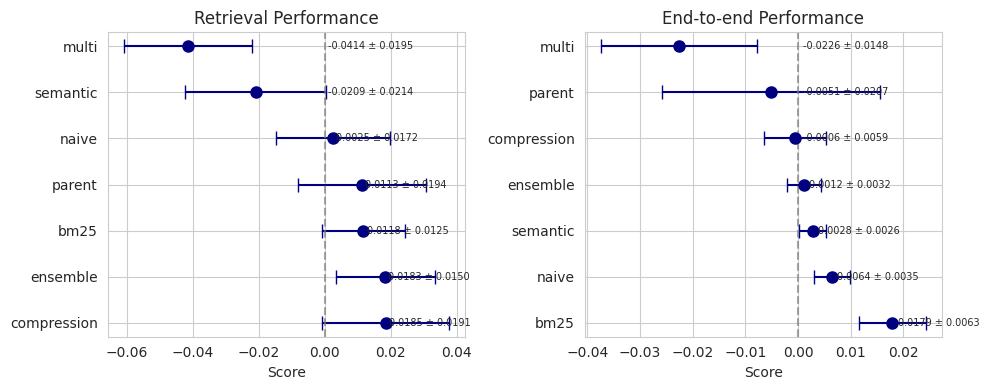

In [108]:
# Create a visualization to compare retrievers based on average score and score variation
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# Create two visualizations:
# 1. Retrieval Performance (retrieval_score vs retrieval_var)
# 2. End-to-end Performance (eoe_score vs eoe_var)

def create_performance_plot(scores_df, score_col, var_col, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    
    sns.set_style("whitegrid")
    
    # Sort by the score column for better visualization
    sorted_df = scores_df.sort_values(score_col, ascending=False)
    
    # Create a horizontal error plot showing scores with error bars
    retrievers = sorted_df.index
    y_pos = np.arange(len(retrievers))
    scores = sorted_df[score_col].values
    variations = sorted_df[var_col].values
    
    # Plot horizontal error bars with central dots
    ax.errorbar(scores, y_pos, xerr=variations, fmt='o', capsize=5, 
               elinewidth=1.5, markersize=8, color='navy')
    
    # Add labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(list(retrievers))
    ax.set_xlabel('Score')
    ax.set_title(title)
    
    # Add a vertical line at x=0 for reference
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
    
    # Add annotations showing the exact values
    for i, (score, var) in enumerate(zip(scores, variations)):
        ax.text(max(score, 0) + 0.001, i, f"{score:.4f} ± {var:.4f}", 
               va='center', fontsize=7)
    
    # Return the axis for further customization if needed
    return ax
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Create the Retrieval Performance plot on the left subplot
create_performance_plot(
    scores_wo_mean_with_variation, 
    'retrieval_score', 
    'retrieval_var', 
    'Retrieval Performance',
    ax=ax1
)

# Create the End-to-end Performance plot on the right subplot
create_performance_plot(
    scores_wo_mean_with_variation, 
    'eoe_score', 
    'eoe_var', 
    'End-to-end Performance',
    ax=ax2
)

# Adjust layout to prevent overlap
plt.tight_layout()






## Costs

I attempted to do a cost analysis in LangSmith but this is one of the parts 
of the material I need to get better at. I assigned names to each of my chains so I can
trace their execution, but I don't know how to aggregate them 
(aside from starting a new project between runs).

![alt text](<langsmith-traces.png>)

On the other hand, I do know how to trace `evaluate()` runs and assign tags, 
but those measure the behavior of the evaluator LLM not the original chain.

Unsurprisingly, all evaluator threads look almost exactly alike.
Since they were run in an `async` `gather` loop, they were concurrent too.

![alt text](langsmith-monitor.png)